In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/Cleaned_Viral_Social_Media_Trends.csv")

df.head()

,Post_ID,Post_Date,Platform,Hashtag,Content_Type,Region,Views,Likes,Shares,Comments,Engagement_Level
0,Post_1,2022-01-13,TikTok,#Challenge,Video,UK,4163464,339431,53135,19346,High
1,Post_2,2022-05-13,Instagram,#Education,Shorts,India,4155940,215240,65860,27239,Medium
2,Post_3,2022-01-07,Twitter,#Challenge,Video,Brazil,3666211,327143,39423,36223,Medium
3,Post_4,2022-12-05,YouTube,#Education,Shorts,Australia,917951,127125,11687,36806,Low
4,Post_5,2023-03-23,TikTok,#Dance,Post,Brazil,64866,171361,69581,6376,Medium


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Post_ID           5000 non-null   str  
 1   Post_Date         5000 non-null   str  
 2   Platform          5000 non-null   str  
 3   Hashtag           5000 non-null   str  
 4   Content_Type      5000 non-null   str  
 5   Region            5000 non-null   str  
 6   Views             5000 non-null   int64
 7   Likes             5000 non-null   int64
 8   Shares            5000 non-null   int64
 9   Comments          5000 non-null   int64
 10  Engagement_Level  5000 non-null   str  
dtypes: int64(4), str(7)
memory usage: 429.8 KB


In [8]:
df.describe()

,Views,Likes,Shares,Comments,engagement,Engagement
count,5.000000e+03,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2.494066e+06,251475.029800,50519.562000,24888.393800,326882.985600,326882.985600
std,1.459490e+06,144349.583384,29066.362671,14284.504319,148089.978422,148089.978422
min,1.266000e+03,490.000000,52.000000,18.000000,12418.000000,12418.000000
25%,1.186207e+06,126892.250000,25029.000000,12305.250000,202019.250000,202019.250000
50%,2.497373e+06,249443.000000,50839.500000,25004.000000,327743.500000,327743.500000
75%,3.759781e+06,373970.750000,75774.250000,37072.750000,450286.500000,450286.500000
max,4.999430e+06,499922.000000,99978.000000,49993.000000,635139.000000,635139.000000


In [ ]:
df["Engagement"] = df["Likes"] + df["Shares"] + df["Comments"]
df.head()

,Post_ID,Post_Date,Platform,Hashtag,Content_Type,Region,Views,Likes,Shares,Comments,Engagement_Level,engagement,Engagement
0,Post_1,2022-01-13,TikTok,#Challenge,Video,UK,4163464,339431,53135,19346,High,411912,411912
1,Post_2,2022-05-13,Instagram,#Education,Shorts,India,4155940,215240,65860,27239,Medium,308339,308339
2,Post_3,2022-01-07,Twitter,#Challenge,Video,Brazil,3666211,327143,39423,36223,Medium,402789,402789
3,Post_4,2022-12-05,YouTube,#Education,Shorts,Australia,917951,127125,11687,36806,Low,175618,175618
4,Post_5,2023-03-23,TikTok,#Dance,Post,Brazil,64866,171361,69581,6376,Medium,247318,247318


In [26]:
platform_engagement = df.groupby("Platform")["Engagement"].sum()
platform_engagement

Platform
Instagram    402853336
TikTok       403771628
Twitter      385959931
YouTube      441830033
Name: Engagement, dtype: int64

In [27]:
platform_engagement = platform_engagement.sort_values(ascending=False)
platform_engagement

Platform
YouTube      441830033
TikTok       403771628
Instagram    402853336
Twitter      385959931
Name: Engagement, dtype: int64

In [28]:
platform_engagement_millions = platform_engagement / 1_000_000
platform_engagement_millions

Platform
YouTube      441.830033
TikTok       403.771628
Instagram    402.853336
Twitter      385.959931
Name: Engagement, dtype: float64

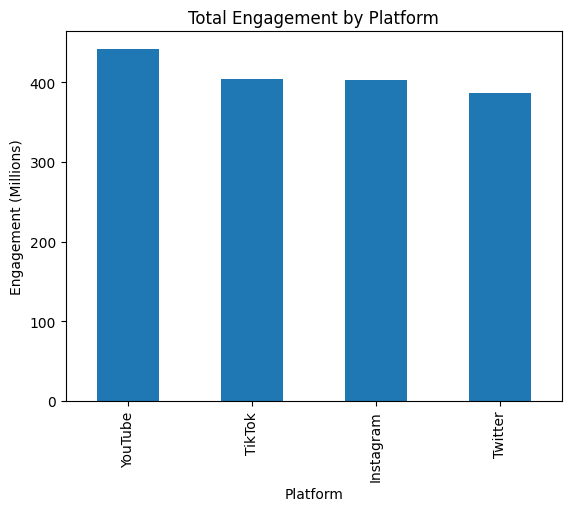

In [42]:
platform_engagement_millions.plot(kind="bar")

plt.title("Total Engagement by Platform")
plt.xlabel("Platform")
plt.ylabel("Engagement (Millions)")

plt.savefig("../outputs/engagement_by_platform.png")

plt.show()

In [33]:
hashtag_engagement = df.groupby("Hashtag")["Engagement"].sum()
hashtag_engagement

Hashtag
#Challenge    161024578
#Comedy       165555504
#Dance        162989514
#Education    176849950
#Fashion      158340183
#Fitness      176261423
#Gaming       153046557
#Music        159733450
#Tech         164207049
#Viral        156406720
Name: Engagement, dtype: int64

In [34]:
hashtag_engagement = hashtag_engagement.sort_values(ascending=False)
hashtag_engagement

Hashtag
#Education    176849950
#Fitness      176261423
#Comedy       165555504
#Tech         164207049
#Dance        162989514
#Challenge    161024578
#Music        159733450
#Fashion      158340183
#Viral        156406720
#Gaming       153046557
Name: Engagement, dtype: int64

In [35]:
hashtag_engagement_millions = hashtag_engagement / 1_000_000
hashtag_engagement_millions

Hashtag
#Education    176.849950
#Fitness      176.261423
#Comedy       165.555504
#Tech         164.207049
#Dance        162.989514
#Challenge    161.024578
#Music        159.733450
#Fashion      158.340183
#Viral        156.406720
#Gaming       153.046557
Name: Engagement, dtype: float64

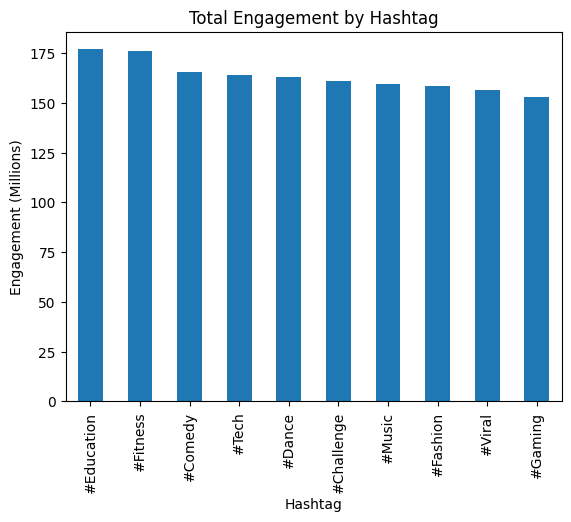

In [43]:
hashtag_engagement_millions.plot(kind="bar")

plt.title("Total Engagement by Hashtag")
plt.xlabel("Hashtag")
plt.ylabel("Engagement (Millions)")

plt.savefig("../outputs/engagement_by_hashtag.png")

plt.show()

In [37]:
region_engagement = df.groupby("Region")["Engagement"].sum()
region_engagement

Region
Australia    198781727
Brazil       207331343
Canada       218245299
Germany      180179687
India        201444997
Japan        197122506
UK           212599877
USA          218709492
Name: Engagement, dtype: int64

In [38]:
region_engagement = region_engagement.sort_values(ascending=False)
region_engagement

Region
USA          218709492
Canada       218245299
UK           212599877
Brazil       207331343
India        201444997
Australia    198781727
Japan        197122506
Germany      180179687
Name: Engagement, dtype: int64

In [39]:
region_engagement_millions = region_engagement / 1_000_000
region_engagement_millions

Region
USA          218.709492
Canada       218.245299
UK           212.599877
Brazil       207.331343
India        201.444997
Australia    198.781727
Japan        197.122506
Germany      180.179687
Name: Engagement, dtype: float64

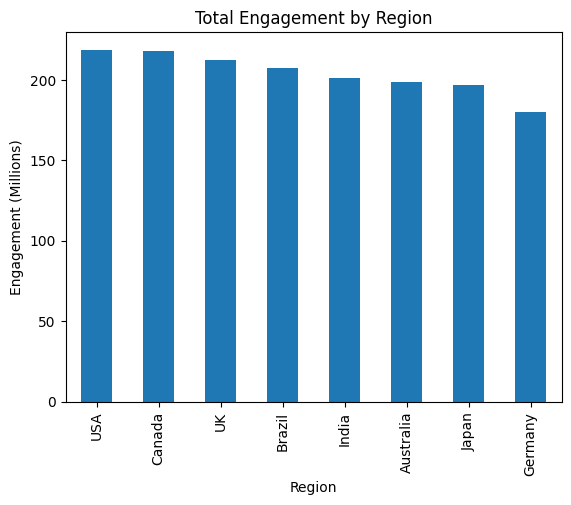

In [41]:
region_engagement_millions.plot(kind="bar")

plt.title("Total Engagement by Region")
plt.xlabel("Region")
plt.ylabel("Engagement (Millions)")

plt.savefig("../outputs/engagement_by_region.png")

plt.show()

## Engagement by Platform

- YouTube generated the highest total engagement (~441.8 million), significantly higher than the other platforms.
- TikTok (~403.8M) and Instagram (~402.9M) show very similar engagement levels, indicating strong performance for short-form visual content.
- Twitter (~386.0M) has the lowest engagement of the four platforms, suggesting it may generate slightly less interaction than video-focused platforms.

## Engagement by Hashtag

- #Education (~176.8M) and #Fitness (~176.3M) produced the highest engagement, showing that informational and lifestyle content resonate strongly with audiences.
- #Comedy (~165.6M) and #Tech (~164.2M) also perform well, suggesting entertainment and technology topics generate strong interaction.
- #Gaming (~153.0M) and #Viral (~156.4M) show the lowest engagement in this dataset, although engagement across hashtags is relatively close overall.

## Engagement by Region

- The USA generated the highest total engagement (~218.7M), followed closely by Canada (~218.2M) and the UK (~212.6M).
- Engagement across most regions is fairly similar, indicating global participation in social media trends.
- Germany (~180.2M) has the lowest engagement among the regions in this dataset.

---

## SQL Version of the Analysis

Below is an example of how the engagement analysis could also be performed using SQL.

### Engagement by Platform

```sql
SELECT 
    Platform,
    SUM(Likes + Shares + Comments) AS Total_Engagement
FROM social_media_engagement
GROUP BY Platform
ORDER BY Total_Engagement DESC;


### Engagement by Hashtag

```sql
SELECT 
    Hashtag,
    SUM(Likes + Shares + Comments) AS Total_Engagement
FROM social_media_engagement
GROUP BY Hashtag
ORDER BY Total_Engagement DESC;

### Engagement by Region

```sql
SELECT 
    Region,
    SUM(Likes + Shares + Comments) AS Total_Engagement
FROM social_media_engagement
GROUP BY Region
ORDER BY Total_Engagement DESC;